**# Solar Power Generation Prediction**

**Data Analysis and Preprocessing**

**Project**: Solar Power Generation Prediction Using Machine Learning

**Purpose:** To analyse the collected solar power and weather datasets and preprocess them for machine learning model development

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
# Define the project root directory
project_root = Path("..")

# Define data directories
raw_data_path = project_root / "data" / "raw_data"
processed_data_path = project_root / "data" / "processed_data"

# Create the processed data directory if it does not exist
processed_data_path.mkdir(parents=True, exist_ok=True)

In [4]:
# Display all files in the raw_data folder
list(raw_data_path.iterdir())


[WindowsPath('../data/raw_data/monthly_solar_generation_summary.csv'),
 WindowsPath('../data/raw_data/solar_power_generation_raw.csv'),
 WindowsPath('../data/raw_data/solar_site_information.csv'),
 WindowsPath('../data/raw_data/weather_conditions_raw.csv')]

In [5]:
# Load the raw datasets

solar_generation_df = pd.read_csv(
    raw_data_path / "solar_power_generation_raw.csv"
)

weather_conditions_df = pd.read_csv(
    raw_data_path / "weather_conditions_raw.csv"
)

solar_site_information_df = pd.read_csv(
    raw_data_path / "solar_site_information.csv"
)

monthly_solar_summary_df = pd.read_csv(
    raw_data_path / "monthly_solar_generation_summary.csv"
)

In [6]:
# Display the number of rows and columns in each dataset

print("Solar Power Generation Dataset:", solar_generation_df.shape)
print("Weather Conditions Dataset:", weather_conditions_df.shape)
print("Solar Site Information Dataset:", solar_site_information_df.shape)
print("Monthly Solar Generation Summary Dataset:", monthly_solar_summary_df.shape)

Solar Power Generation Dataset: (2731946, 4)
Weather Conditions Dataset: (371769, 8)
Solar Site Information Dataset: (42, 10)
Monthly Solar Generation Summary Dataset: (1176, 7)


In [7]:
# Display the column names of each dataset

print("Solar Power Generation Columns:")
print(solar_generation_df.columns.tolist())

print("\nWeather Conditions Columns:")
print(weather_conditions_df.columns.tolist())

print("\nSolar Site Information Columns:")
print(solar_site_information_df.columns.tolist())

print("\nMonthly Solar Generation Summary Columns:")
print(monthly_solar_summary_df.columns.tolist())

Solar Power Generation Columns:
['CampusKey', 'SiteKey', 'Timestamp', 'SolarGeneration']

Weather Conditions Columns:
['CampusKey', 'Timestamp', 'ApparentTemperature', 'AirTemperature', 'DewPointTemperature', 'RelativeHumidity', 'WindSpeed', 'WindDirection']

Solar Site Information Columns:
['CampusKey', 'SiteKey', 'kWp', 'Number of panels', 'Panel', 'Inverter', 'Optimizers', 'Metric', 'lat', 'Lon']

Monthly Solar Generation Summary Columns:
['SiteKey', 'Year', 'Month', 'DataStatus', 'AverageSolarGeneration', 'MaxSolarGeneration', 'MinSolarGeneration']


In [8]:
# Display the first 5 rows of each dataset

print("SOLAR POWER GENERATION DATASET")
display(solar_generation_df.head())

print("WEATHER CONDITIONS DATASET")
display(weather_conditions_df.head())

print("SOLAR SITE INFORMATION DATASET")
display(solar_site_information_df.head())

print("MONTHLY SOLAR GENERATION SUMMARY DATASET")
display(monthly_solar_summary_df.head())

SOLAR POWER GENERATION DATASET


,CampusKey,SiteKey,Timestamp,SolarGeneration
0,2,1,2020-01-01 00:15:00,NaN
1,2,1,2020-01-01 00:30:00,NaN
2,2,1,2020-01-01 00:45:00,NaN
3,2,1,2020-01-01 01:00:00,NaN
4,2,1,2020-01-01 01:15:00,NaN


WEATHER CONDITIONS DATASET


,CampusKey,Timestamp,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,WindSpeed,WindDirection
0,1,2020-01-01 00:00:00,13.666667,13.880000,8.960000,72.400000,0.000000,188.133333
1,1,2020-01-01 00:15:00,13.206667,13.666667,9.040000,73.466667,1.200000,203.866667
2,1,2020-01-01 00:30:00,12.840000,13.553333,9.053333,74.000000,2.520000,222.800000
3,1,2020-01-01 00:45:00,12.113333,13.506667,9.100000,74.466667,5.986667,231.133333
4,1,2020-01-01 01:00:00,11.946667,13.260000,9.266667,76.533333,5.946667,247.866667


SOLAR SITE INFORMATION DATASET


,CampusKey,SiteKey,kWp,Number of panels,Panel,Inverter,Optimizers,Metric,lat,Lon
0,2,1,NaN,NaN,NaN,NaN,NaN,NaN,-36.111209,146.848679
1,2,2,NaN,NaN,NaN,NaN,NaN,NaN,-36.111209,146.848679
2,2,3,NaN,NaN,NaN,NaN,NaN,NaN,-36.111209,146.848679
3,2,4,NaN,NaN,NaN,NaN,NaN,NaN,-36.111209,146.848679
4,2,5,NaN,NaN,NaN,NaN,NaN,NaN,-36.111209,146.848679


MONTHLY SOLAR GENERATION SUMMARY DATASET


,SiteKey,Year,Month,DataStatus,AverageSolarGeneration,MaxSolarGeneration,MinSolarGeneration
0,1,2020,January,True,10.157125,21.778,0.101
1,2,2020,January,True,8.536875,18.553,0.100
2,3,2020,January,True,6.309834,13.322,0.103
3,4,2020,January,False,NaN,NaN,NaN
4,5,2020,January,False,NaN,NaN,NaN


In [9]:
# Display detailed information about each dataset

print("SOLAR POWER GENERATION DATASET")
solar_generation_df.info()

print("\n" + "=" * 60 + "\n")

print("WEATHER CONDITIONS DATASET")
weather_conditions_df.info()

print("\n" + "=" * 60 + "\n")

print("SOLAR SITE INFORMATION DATASET")
solar_site_information_df.info()

print("\n" + "=" * 60 + "\n")

print("MONTHLY SOLAR GENERATION SUMMARY DATASET")
monthly_solar_summary_df.info()

SOLAR POWER GENERATION DATASET
<class 'pandas.DataFrame'>
RangeIndex: 2731946 entries, 0 to 2731945
Data columns (total 4 columns):
 #   Column           Dtype  
---  ------           -----  
 0   CampusKey        int64  
 1   SiteKey          int64  
 2   Timestamp        str    
 3   SolarGeneration  float64
dtypes: float64(1), int64(2), str(1)
memory usage: 132.9 MB


WEATHER CONDITIONS DATASET
<class 'pandas.DataFrame'>
RangeIndex: 371769 entries, 0 to 371768
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   CampusKey            371769 non-null  int64  
 1   Timestamp            371769 non-null  str    
 2   ApparentTemperature  264656 non-null  float64
 3   AirTemperature       264656 non-null  float64
 4   DewPointTemperature  264656 non-null  float64
 5   RelativeHumidity     264656 non-null  float64
 6   WindSpeed            208879 non-null  float64
 7   WindDirection        208879 non-null

In [10]:
# Calculate missing values in each dataset

datasets = {
    "Solar Power Generation": solar_generation_df,
    "Weather Conditions": weather_conditions_df,
    "Solar Site Information": solar_site_information_df,
    "Monthly Solar Generation Summary": monthly_solar_summary_df
}

for dataset_name, dataset in datasets.items():
    print(f"\n{dataset_name}")
    print("=" * 60)
    
    missing_values = dataset.isnull().sum()
    missing_percentage = (missing_values / len(dataset)) * 100
    
    missing_summary = pd.DataFrame({
        "Missing Values": missing_values,
        "Missing Percentage": missing_percentage
    })
    
    print(missing_summary)


Solar Power Generation
                 Missing Values  Missing Percentage
CampusKey                     0            0.000000
SiteKey                       0            0.000000
Timestamp                     0            0.000000
SolarGeneration         1536301           56.234677

Weather Conditions
                     Missing Values  Missing Percentage
CampusKey                         0            0.000000
Timestamp                         0            0.000000
ApparentTemperature          107113           28.811708
AirTemperature               107113           28.811708
DewPointTemperature          107113           28.811708
RelativeHumidity             107113           28.811708
WindSpeed                    162890           43.814842
WindDirection                162890           43.814842

Solar Site Information
                  Missing Values  Missing Percentage
CampusKey                      0            0.000000
SiteKey                        0            0.000000
kWp      

In [11]:
# Analyse missing SolarGeneration values by hour

solar_generation_analysis = solar_generation_df.copy()

# Convert Timestamp to datetime for analysis
solar_generation_analysis["Timestamp"] = pd.to_datetime(
    solar_generation_analysis["Timestamp"]
)

# Extract hour from Timestamp
solar_generation_analysis["Hour"] = (
    solar_generation_analysis["Timestamp"].dt.hour
)

# Calculate missing SolarGeneration values for each hour
missing_by_hour = (
    solar_generation_analysis
    .groupby("Hour")["SolarGeneration"]
    .apply(lambda x: x.isna().sum())
)

# Calculate total records for each hour
total_by_hour = (
    solar_generation_analysis
    .groupby("Hour")["SolarGeneration"]
    .size()
)

# Create a summary
missing_hour_summary = pd.DataFrame({
    "Total Records": total_by_hour,
    "Missing SolarGeneration": missing_by_hour
})

missing_hour_summary["Missing Percentage"] = (
    missing_hour_summary["Missing SolarGeneration"]
    / missing_hour_summary["Total Records"]
) * 100

missing_hour_summary

,Total Records,Missing SolarGeneration,Missing Percentage
Hour,,,
0,114089,114050,99.965816
1,114494,114447,99.958950
2,114356,114325,99.972892
3,114492,114464,99.975544
4,114470,114438,99.972045
5,114326,114297,99.974634
6,114272,103891,90.915535
7,114236,56296,49.280437
8,114071,14685,12.873561


In [12]:
# Analyse existing zero and non-zero SolarGeneration values

solar_generation_analysis["SolarGeneration"].value_counts().head(10)

SolarGeneration
0.125000    4869
0.187500    4049
0.500000    4039
0.250000    3611
0.312500    3248
0.156250    3148
0.375000    3037
0.218750    2883
1.000000    2828
0.101562    2775
Name: count, dtype: int64

In [13]:
# Count zero and non-zero values

zero_generation_count = (
    solar_generation_analysis["SolarGeneration"] == 0
).sum()

non_zero_generation_count = (
    solar_generation_analysis["SolarGeneration"] > 0
).sum()

print("Zero SolarGeneration values:", zero_generation_count)
print("Non-zero SolarGeneration values:", non_zero_generation_count)

Zero SolarGeneration values: 0
Non-zero SolarGeneration values: 1195645


In [14]:
# Check duplicate rows in each dataset

datasets = {
    "Solar Power Generation": solar_generation_df,
    "Weather Conditions": weather_conditions_df,
    "Solar Site Information": solar_site_information_df,
    "Monthly Solar Generation Summary": monthly_solar_summary_df
}

for dataset_name, dataset in datasets.items():
    duplicate_count = dataset.duplicated().sum()
    print(f"{dataset_name}: {duplicate_count} duplicate rows")

Solar Power Generation: 0 duplicate rows
Weather Conditions: 0 duplicate rows
Solar Site Information: 0 duplicate rows
Monthly Solar Generation Summary: 0 duplicate rows


In [15]:
# Convert Timestamp column to datetime format

solar_generation_df["Timestamp"] = pd.to_datetime(
    solar_generation_df["Timestamp"]
)

# Verify the updated data type
print("Timestamp data type:", solar_generation_df["Timestamp"].dtype)

# Display the first few rows
solar_generation_df.head()

Timestamp data type: datetime64[us]


,CampusKey,SiteKey,Timestamp,SolarGeneration
0,2,1,2020-01-01 00:15:00,NaN
1,2,1,2020-01-01 00:30:00,NaN
2,2,1,2020-01-01 00:45:00,NaN
3,2,1,2020-01-01 01:00:00,NaN
4,2,1,2020-01-01 01:15:00,NaN


In [16]:
# Remove rows where the target variable SolarGeneration is missing

solar_generation_cleaned_df = solar_generation_df.dropna(
    subset=["SolarGeneration"]
).copy()

# Display the number of records before and after removing missing values

print("Rows before removing missing SolarGeneration values:", len(solar_generation_df))
print("Rows after removing missing SolarGeneration values:", len(solar_generation_cleaned_df))
print("Rows removed:", len(solar_generation_df) - len(solar_generation_cleaned_df))

# Check remaining missing values
print("\nRemaining missing SolarGeneration values:",
      solar_generation_cleaned_df["SolarGeneration"].isnull().sum())

Rows before removing missing SolarGeneration values: 2731946
Rows after removing missing SolarGeneration values: 1195645
Rows removed: 1536301

Remaining missing SolarGeneration values: 0


In [17]:
# Convert the weather Timestamp column to datetime format

weather_conditions_df["Timestamp"] = pd.to_datetime(
    weather_conditions_df["Timestamp"]
)

# Verify the updated data type
print("Weather Timestamp data type:",
      weather_conditions_df["Timestamp"].dtype)

# Display the first few rows
weather_conditions_df.head()

Weather Timestamp data type: datetime64[us]


,CampusKey,Timestamp,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,WindSpeed,WindDirection
0,1,2020-01-01 00:00:00,13.666667,13.880000,8.960000,72.400000,0.000000,188.133333
1,1,2020-01-01 00:15:00,13.206667,13.666667,9.040000,73.466667,1.200000,203.866667
2,1,2020-01-01 00:30:00,12.840000,13.553333,9.053333,74.000000,2.520000,222.800000
3,1,2020-01-01 00:45:00,12.113333,13.506667,9.100000,74.466667,5.986667,231.133333
4,1,2020-01-01 01:00:00,11.946667,13.260000,9.266667,76.533333,5.946667,247.866667


In [18]:
# Compare CampusKey values in both datasets

print("Solar Generation Campus Keys:")
print(sorted(solar_generation_cleaned_df["CampusKey"].unique()))

print("\nWeather Conditions Campus Keys:")
print(sorted(weather_conditions_df["CampusKey"].unique()))

Solar Generation Campus Keys:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Weather Conditions Campus Keys:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [19]:
# Check the date range of both main datasets

print("Solar Generation Dataset")
print("Start:", solar_generation_cleaned_df["Timestamp"].min())
print("End:", solar_generation_cleaned_df["Timestamp"].max())

print("\nWeather Conditions Dataset")
print("Start:", weather_conditions_df["Timestamp"].min())
print("End:", weather_conditions_df["Timestamp"].max())

Solar Generation Dataset
Start: 2020-01-01 06:15:00
End: 2022-04-23 23:15:00

Weather Conditions Dataset
Start: 2020-01-01 00:00:00
End: 2022-04-23 22:00:00


In [20]:
# Check duplicate CampusKey + Timestamp combinations

solar_duplicate_keys = (
    solar_generation_cleaned_df
    .duplicated(subset=["CampusKey", "Timestamp"])
    .sum()
)

weather_duplicate_keys = (
    weather_conditions_df
    .duplicated(subset=["CampusKey", "Timestamp"])
    .sum()
)

print("Duplicate CampusKey + Timestamp keys in Solar Generation:",
      solar_duplicate_keys)

print("Duplicate CampusKey + Timestamp keys in Weather Conditions:",
      weather_duplicate_keys)

Duplicate CampusKey + Timestamp keys in Solar Generation: 1005214
Duplicate CampusKey + Timestamp keys in Weather Conditions: 0


In [21]:
# Check duplicate complete identifiers in the solar generation dataset

solar_complete_duplicate_keys = (
    solar_generation_cleaned_df
    .duplicated(subset=["CampusKey", "SiteKey", "Timestamp"])
    .sum()
)

print(
    "Duplicate CampusKey + SiteKey + Timestamp combinations:",
    solar_complete_duplicate_keys
)

Duplicate CampusKey + SiteKey + Timestamp combinations: 0


In [22]:
# Count solar sites in each campus

sites_per_campus = (
    solar_generation_cleaned_df
    .groupby("CampusKey")["SiteKey"]
    .nunique()
)

print(sites_per_campus)

CampusKey
1    27
2     5
3     8
4     1
5     1
Name: SiteKey, dtype: int64


In [23]:
# Merge solar generation data with weather conditions

merged_solar_weather_df = pd.merge(
    solar_generation_cleaned_df,
    weather_conditions_df,
    on=["CampusKey", "Timestamp"],
    how="left"
)

# Display the shape of the merged dataset
print("Merged dataset shape:", merged_solar_weather_df.shape)

# Display the first 5 rows
merged_solar_weather_df.head()

Merged dataset shape: (1195645, 10)


,CampusKey,SiteKey,Timestamp,SolarGeneration,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,WindSpeed,WindDirection
0,2,1,2020-01-01 06:15:00,0.135,13.973333,15.246667,9.146667,67.000000,5.746667,172.866667
1,2,1,2020-01-01 06:30:00,0.465,13.800000,15.213333,9.166667,67.266667,6.426667,174.733333
2,2,1,2020-01-01 06:45:00,1.039,13.693333,15.160000,9.260000,68.000000,6.866667,189.600000
3,2,1,2020-01-01 07:00:00,1.673,13.826667,15.546667,9.446667,67.000000,8.293333,179.200000
4,2,1,2020-01-01 07:15:00,2.560,14.360000,15.920000,9.606667,66.000000,7.640000,187.200000


In [24]:
# Check missing values in the merged dataset

missing_values = merged_solar_weather_df.isnull().sum()

missing_percentage = (
    missing_values / len(merged_solar_weather_df)
) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_summary

,Missing Values,Missing Percentage
CampusKey,0,0.000000
SiteKey,0,0.000000
Timestamp,0,0.000000
SolarGeneration,0,0.000000
ApparentTemperature,289309,24.196898
AirTemperature,289309,24.196898
DewPointTemperature,289309,24.196898
RelativeHumidity,289309,24.196898
WindSpeed,546772,45.730296
WindDirection,546772,45.730296


In [25]:
# Check missing values in weather features for each campus

weather_columns = [
    "ApparentTemperature",
    "AirTemperature",
    "DewPointTemperature",
    "RelativeHumidity",
    "WindSpeed",
    "WindDirection"
]

missing_by_campus = (
    merged_solar_weather_df
    .groupby("CampusKey")[weather_columns]
    .apply(lambda x: x.isnull().mean() * 100)
)

missing_by_campus

,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,WindSpeed,WindDirection
CampusKey,,,,,,
1,24.294122,24.294122,24.294122,24.294122,48.843777,48.843777
2,19.440514,19.440514,19.440514,19.440514,39.407904,39.407904
3,14.292609,14.292609,14.292609,14.292609,29.347231,29.347231
4,42.675947,42.675947,42.675947,42.675947,54.690565,54.690565
5,83.029548,83.029548,83.029548,83.029548,95.867769,95.867769


In [26]:
# Check the length of consecutive missing periods for AirTemperature

def get_missing_block_lengths(series):
    missing = series.isnull()

    # Create groups of consecutive missing/non-missing values
    groups = missing.ne(missing.shift()).cumsum()

    # Count consecutive missing values
    missing_blocks = (
        missing.groupby(groups)
        .sum()
    )

    # Keep only blocks that contain missing values
    missing_blocks = missing_blocks[missing_blocks > 0]

    return missing_blocks


# Find the longest missing block for each campus

for campus in sorted(merged_solar_weather_df["CampusKey"].unique()):

    campus_data = (
        merged_solar_weather_df[
            merged_solar_weather_df["CampusKey"] == campus
        ]
        .sort_values("Timestamp")
    )

    missing_blocks = get_missing_block_lengths(
        campus_data["AirTemperature"]
    )

    print(
        f"Campus {campus} - Longest consecutive missing block:",
        missing_blocks.max()
    )

Campus 1 - Longest consecutive missing block: 232
Campus 2 - Longest consecutive missing block: 645
Campus 3 - Longest consecutive missing block: 93
Campus 4 - Longest consecutive missing block: 11578
Campus 5 - Longest consecutive missing block: 14146


In [27]:
# Check the longest consecutive missing blocks in the original weather dataset

for campus in sorted(weather_conditions_df["CampusKey"].unique()):

    campus_weather = (
        weather_conditions_df[
            weather_conditions_df["CampusKey"] == campus
        ]
        .sort_values("Timestamp")
    )

    missing_blocks = get_missing_block_lengths(
        campus_weather["AirTemperature"]
    )

    print(
        f"Campus {campus} - Longest consecutive missing block:",
        missing_blocks.max()
    )

Campus 1 - Longest consecutive missing block: 41
Campus 2 - Longest consecutive missing block: 377
Campus 3 - Longest consecutive missing block: 40
Campus 4 - Longest consecutive missing block: 26457
Campus 5 - Longest consecutive missing block: 26457


In [28]:
# Count valid solar generation records for each campus

records_per_campus = (
    solar_generation_cleaned_df
    .groupby("CampusKey")
    .size()
)

records_per_campus

CampusKey
1    759196
2    148422
3    215482
4     37213
5     35332
dtype: int64

In [29]:
# Create a copy of the weather dataset for preprocessing

weather_cleaned_df = weather_conditions_df.copy()

# Keep only campuses with sufficient weather data
weather_cleaned_df = weather_cleaned_df[
    weather_cleaned_df["CampusKey"].isin([1, 2, 3])
].copy()

# Sort the data before interpolation
weather_cleaned_df = weather_cleaned_df.sort_values(
    ["CampusKey", "Timestamp"]
).reset_index(drop=True)

print("Weather dataset shape after removing Campuses 4 and 5:")
print(weather_cleaned_df.shape)

print("\nRemaining campuses:")
print(sorted(weather_cleaned_df["CampusKey"].unique()))

Weather dataset shape after removing Campuses 4 and 5:
(243051, 8)

Remaining campuses:
[np.int64(1), np.int64(2), np.int64(3)]


In [30]:
# Weather columns to be interpolated

weather_columns = [
    "ApparentTemperature",
    "AirTemperature",
    "DewPointTemperature",
    "RelativeHumidity",
    "WindSpeed",
    "WindDirection"
]

# Interpolate missing values within each CampusKey
weather_cleaned_df[weather_columns] = (
    weather_cleaned_df
    .groupby("CampusKey")[weather_columns]
    .transform(
        lambda x: x.interpolate(
            method="linear",
            limit=96,
            limit_area="inside"
        )
    )
)

# Check remaining missing values
print(
    weather_cleaned_df[weather_columns]
    .isnull()
    .sum()
)

ApparentTemperature      281
AirTemperature           281
DewPointTemperature      281
RelativeHumidity         281
WindSpeed              73418
WindDirection          73418
dtype: int64


In [31]:
# Fill remaining missing temperature and humidity values
# using the median value of the corresponding campus

temperature_columns = [
    "ApparentTemperature",
    "AirTemperature",
    "DewPointTemperature",
    "RelativeHumidity"
]

for column in temperature_columns:
    weather_cleaned_df[column] = (
        weather_cleaned_df
        .groupby("CampusKey")[column]
        .transform(lambda x: x.fillna(x.median()))
    )

# Check remaining missing values
print(
    weather_cleaned_df[temperature_columns]
    .isnull()
    .sum()
)

ApparentTemperature    0
AirTemperature         0
DewPointTemperature    0
RelativeHumidity       0
dtype: int64


In [32]:
# Remove highly incomplete wind-related features

weather_cleaned_df = weather_cleaned_df.drop(
    columns=["WindSpeed", "WindDirection"]
)

# Verify the dataset
print("Final weather dataset shape:", weather_cleaned_df.shape)

print("\nColumns:")
print(weather_cleaned_df.columns.tolist())

print("\nMissing values:")
print(weather_cleaned_df.isnull().sum())

Final weather dataset shape: (243051, 6)

Columns:
['CampusKey', 'Timestamp', 'ApparentTemperature', 'AirTemperature', 'DewPointTemperature', 'RelativeHumidity']

Missing values:
CampusKey              0
Timestamp              0
ApparentTemperature    0
AirTemperature         0
DewPointTemperature    0
RelativeHumidity       0
dtype: int64


In [33]:
# Keep solar generation data only for Campuses 1, 2, and 3

solar_model_df = solar_generation_cleaned_df[
    solar_generation_cleaned_df["CampusKey"].isin([1, 2, 3])
].copy()

print("Solar generation dataset shape for modeling:")
print(solar_model_df.shape)

print("\nRemaining campuses:")
print(sorted(solar_model_df["CampusKey"].unique()))

Solar generation dataset shape for modeling:
(1123100, 4)

Remaining campuses:
[np.int64(1), np.int64(2), np.int64(3)]


In [34]:
# Merge cleaned solar generation data with cleaned weather data

final_preprocessed_df = pd.merge(
    solar_model_df,
    weather_cleaned_df,
    on=["CampusKey", "Timestamp"],
    how="left"
)

# Display dataset shape
print("Final merged dataset shape:")
print(final_preprocessed_df.shape)

# Check for missing values
print("\nMissing values after merging:")
print(final_preprocessed_df.isnull().sum())

# Display the first 5 rows
final_preprocessed_df.head()

Final merged dataset shape:
(1123100, 8)

Missing values after merging:
CampusKey              0
SiteKey                0
Timestamp              0
SolarGeneration        0
ApparentTemperature    1
AirTemperature         1
DewPointTemperature    1
RelativeHumidity       1
dtype: int64


,CampusKey,SiteKey,Timestamp,SolarGeneration,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity
0,2,1,2020-01-01 06:15:00,0.135,13.973333,15.246667,9.146667,67.000000
1,2,1,2020-01-01 06:30:00,0.465,13.800000,15.213333,9.166667,67.266667
2,2,1,2020-01-01 06:45:00,1.039,13.693333,15.160000,9.260000,68.000000
3,2,1,2020-01-01 07:00:00,1.673,13.826667,15.546667,9.446667,67.000000
4,2,1,2020-01-01 07:15:00,2.560,14.360000,15.920000,9.606667,66.000000


In [35]:
# Display the row with missing weather information

unmatched_weather_record = final_preprocessed_df[
    final_preprocessed_df["ApparentTemperature"].isnull()
]

unmatched_weather_record

,CampusKey,SiteKey,Timestamp,SolarGeneration,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity
760921,1,27,2022-04-23 23:15:00,0.125,NaN,NaN,NaN,NaN


In [36]:
# Remove rows with missing weather information

final_preprocessed_df = final_preprocessed_df.dropna().copy()

# Reset the index
final_preprocessed_df = final_preprocessed_df.reset_index(drop=True)

# Verify the final dataset
print("Final dataset shape:", final_preprocessed_df.shape)

print("\nMissing values:")
print(final_preprocessed_df.isnull().sum())

Final dataset shape: (1123099, 8)

Missing values:
CampusKey              0
SiteKey                0
Timestamp              0
SolarGeneration        0
ApparentTemperature    0
AirTemperature         0
DewPointTemperature    0
RelativeHumidity       0
dtype: int64


In [37]:
# Create time-based features from Timestamp

final_preprocessed_df["Year"] = (
    final_preprocessed_df["Timestamp"].dt.year
)

final_preprocessed_df["Month"] = (
    final_preprocessed_df["Timestamp"].dt.month
)

final_preprocessed_df["Day"] = (
    final_preprocessed_df["Timestamp"].dt.day
)

final_preprocessed_df["Hour"] = (
    final_preprocessed_df["Timestamp"].dt.hour
)

final_preprocessed_df["DayOfWeek"] = (
    final_preprocessed_df["Timestamp"].dt.dayofweek
)

# Display the updated dataset
final_preprocessed_df.head()

,CampusKey,SiteKey,Timestamp,SolarGeneration,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,Year,Month,Day,Hour,DayOfWeek
0,2,1,2020-01-01 06:15:00,0.135,13.973333,15.246667,9.146667,67.000000,2020,1,1,6,2
1,2,1,2020-01-01 06:30:00,0.465,13.800000,15.213333,9.166667,67.266667,2020,1,1,6,2
2,2,1,2020-01-01 06:45:00,1.039,13.693333,15.160000,9.260000,68.000000,2020,1,1,6,2
3,2,1,2020-01-01 07:00:00,1.673,13.826667,15.546667,9.446667,67.000000,2020,1,1,7,2
4,2,1,2020-01-01 07:15:00,2.560,14.360000,15.920000,9.606667,66.000000,2020,1,1,7,2


In [38]:
# Display statistical summary of numerical columns

numerical_columns = [
    "SolarGeneration",
    "ApparentTemperature",
    "AirTemperature",
    "DewPointTemperature",
    "RelativeHumidity"
]

final_preprocessed_df[numerical_columns].describe()

,SolarGeneration,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity
count,1.123099e+06,1.123099e+06,1.123099e+06,1.123099e+06,1.123099e+06
mean,7.027549e+00,1.577376e+01,1.805434e+01,9.750842e+00,6.273285e+01
std,1.146982e+01,7.015286e+00,6.484254e+00,4.044893e+00,2.145146e+01
min,1.000000e-01,-5.646667e+00,-1.873333e+00,-1.026667e+01,3.066667e+00
25%,1.121094e+00,1.050000e+01,1.339333e+01,6.786667e+00,4.746667e+01
50%,3.289062e+00,1.479333e+01,1.717333e+01,9.420000e+00,6.080000e+01
75%,8.054688e+00,2.059333e+01,2.215000e+01,1.242000e+01,7.800000e+01
max,9.921880e+01,4.158667e+01,4.540000e+01,2.532000e+01,1.000000e+02


In [39]:
# Check for invalid negative solar generation values

negative_solar_generation = (
    final_preprocessed_df["SolarGeneration"] < 0
).sum()

print(
    "Number of negative SolarGeneration values:",
    negative_solar_generation
)

Number of negative SolarGeneration values: 0


In [40]:
# Check for invalid humidity values

invalid_humidity = (
    (final_preprocessed_df["RelativeHumidity"] < 0) |
    (final_preprocessed_df["RelativeHumidity"] > 100)
).sum()

print(
    "Number of invalid RelativeHumidity values:",
    invalid_humidity
)

Number of invalid RelativeHumidity values: 0


In [41]:
# Save the final preprocessed dataset

output_path = "../data/processed_data/solar_power_generation_preprocessed.csv"

final_preprocessed_df.to_csv(
    output_path,
    index=False
)

print("Preprocessed dataset saved successfully!")
print("Location:", output_path)

print("\nFinal dataset shape:")
print(final_preprocessed_df.shape)

Preprocessed dataset saved successfully!
Location: ../data/processed_data/solar_power_generation_preprocessed.csv

Final dataset shape:
(1123099, 13)


In [42]:
# Load the saved dataset and verify it

saved_preprocessed_df = pd.read_csv(
    "../data/processed_data/solar_power_generation_preprocessed.csv"
)

print("Saved dataset shape:")
print(saved_preprocessed_df.shape)

print("\nFirst 5 rows:")
print(saved_preprocessed_df.head())

Saved dataset shape:
(1123099, 13)

First 5 rows:
   CampusKey  SiteKey            Timestamp  SolarGeneration  \
0          2        1  2020-01-01 06:15:00            0.135   
1          2        1  2020-01-01 06:30:00            0.465   
2          2        1  2020-01-01 06:45:00            1.039   
3          2        1  2020-01-01 07:00:00            1.673   
4          2        1  2020-01-01 07:15:00            2.560   

   ApparentTemperature  AirTemperature  DewPointTemperature  RelativeHumidity  \
0            13.973333       15.246667             9.146667         67.000000   
1            13.800000       15.213333             9.166667         67.266667   
2            13.693333       15.160000             9.260000         68.000000   
3            13.826667       15.546667             9.446667         67.000000   
4            14.360000       15.920000             9.606667         66.000000   

   Year  Month  Day  Hour  DayOfWeek  
0  2020      1    1     6          2  
1  202

In [43]:
# Dataset size comparison

preprocessing_size_comparison = pd.DataFrame({
    "Stage": [
        "Original Solar Generation Dataset",
        "After Removing Missing SolarGeneration",
        "After Selecting Campuses 1, 2 and 3",
        "Final Preprocessed Dataset"
    ],
    "Rows": [
        2731946,
        1195645,
        1123100,
        1123099
    ]
})

preprocessing_size_comparison

,Stage,Rows
0,Original Solar Generation Dataset,2731946
1,After Removing Missing SolarGeneration,1195645
2,"After Selecting Campuses 1, 2 and 3",1123100
3,Final Preprocessed Dataset,1123099


In [44]:
# Missing values before and after preprocessing

missing_values_comparison = pd.DataFrame({
    "Feature": [
        "SolarGeneration",
        "ApparentTemperature",
        "AirTemperature",
        "DewPointTemperature",
        "RelativeHumidity"
    ],
    
    "Missing Before Preprocessing": [
        1536301,
        107113,
        107113,
        107113,
        107113
    ],
    
    "Missing After Preprocessing": [
        0,
        0,
        0,
        0,
        0
    ]
})

missing_values_comparison

,Feature,Missing Before Preprocessing,Missing After Preprocessing
0,SolarGeneration,1536301,0
1,ApparentTemperature,107113,0
2,AirTemperature,107113,0
3,DewPointTemperature,107113,0
4,RelativeHumidity,107113,0


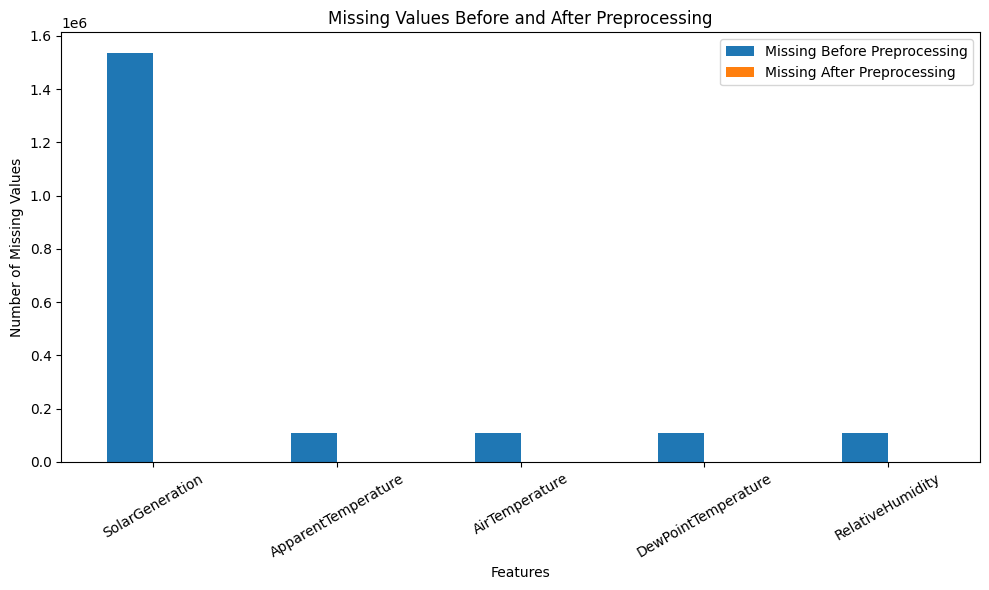

In [45]:
import matplotlib.pyplot as plt

# Create a bar chart

missing_values_comparison.set_index("Feature").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Missing Values Before and After Preprocessing")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

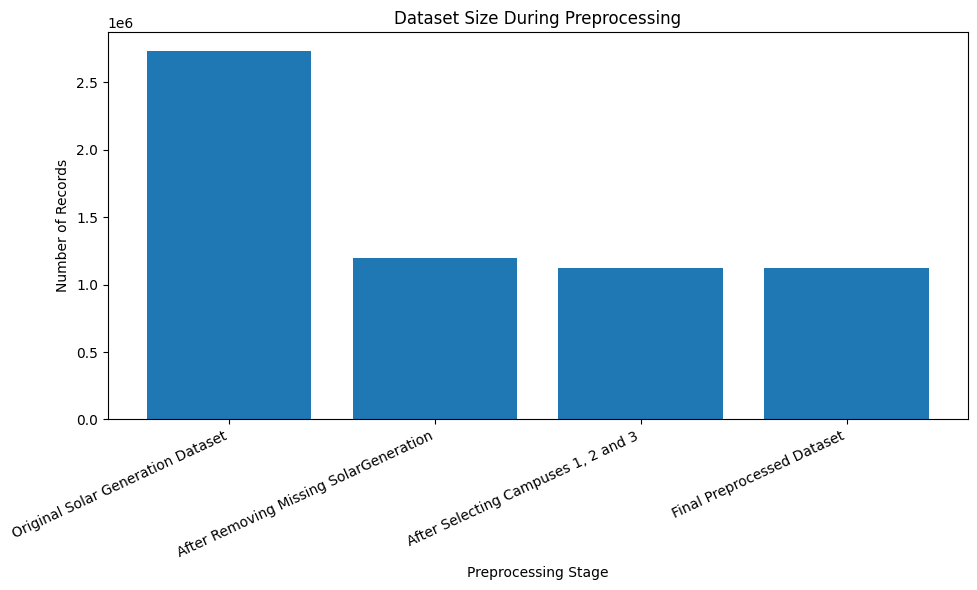

In [46]:
# Plot dataset size across preprocessing stages

plt.figure(figsize=(10, 6))

plt.bar(
    preprocessing_size_comparison["Stage"],
    preprocessing_size_comparison["Rows"]
)

plt.title("Dataset Size During Preprocessing")
plt.xlabel("Preprocessing Stage")
plt.ylabel("Number of Records")
plt.xticks(rotation=25, ha="right")

plt.tight_layout()

plt.show()

In [47]:
# Final dataset information

print("FINAL PREPROCESSED DATASET")

print("\nDataset Shape:")
print(final_preprocessed_df.shape)

print("\nTotal Missing Values:")
print(final_preprocessed_df.isnull().sum().sum())

print("\nNumber of Duplicate Rows:")
print(final_preprocessed_df.duplicated().sum())

print("\nColumns:")
print(final_preprocessed_df.columns.tolist())

FINAL PREPROCESSED DATASET

Dataset Shape:
(1123099, 13)

Total Missing Values:
0

Number of Duplicate Rows:
0

Columns:
['CampusKey', 'SiteKey', 'Timestamp', 'SolarGeneration', 'ApparentTemperature', 'AirTemperature', 'DewPointTemperature', 'RelativeHumidity', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek']


In [48]:
# Display a sample of the final preprocessed dataset

final_preprocessed_df.head(10)

,CampusKey,SiteKey,Timestamp,SolarGeneration,ApparentTemperature,AirTemperature,DewPointTemperature,RelativeHumidity,Year,Month,Day,Hour,DayOfWeek
0,2,1,2020-01-01 06:15:00,0.135,13.973333,15.246667,9.146667,67.000000,2020,1,1,6,2
1,2,1,2020-01-01 06:30:00,0.465,13.800000,15.213333,9.166667,67.266667,2020,1,1,6,2
2,2,1,2020-01-01 06:45:00,1.039,13.693333,15.160000,9.260000,68.000000,2020,1,1,6,2
3,2,1,2020-01-01 07:00:00,1.673,13.826667,15.546667,9.446667,67.000000,2020,1,1,7,2
4,2,1,2020-01-01 07:15:00,2.560,14.360000,15.920000,9.606667,66.000000,2020,1,1,7,2
5,2,1,2020-01-01 07:30:00,3.553,14.606667,16.560000,9.713333,63.933333,2020,1,1,7,2
6,2,1,2020-01-01 07:45:00,4.647,15.753333,17.233333,9.746667,61.400000,2020,1,1,7,2
7,2,1,2020-01-01 08:00:00,5.934,16.333333,17.753333,9.746667,59.333333,2020,1,1,8,2
8,2,1,2020-01-01 08:15:00,7.113,16.900000,18.166667,9.726667,57.866667,2020,1,1,8,2
9,2,1,2020-01-01 08:30:00,8.485,17.713333,18.840000,9.920000,56.200000,2020,1,1,8,2


In [49]:
# Separate input features and target variable

target_variable = "SolarGeneration"

input_features = [
    column
    for column in final_preprocessed_df.columns
    if column not in ["SolarGeneration", "Timestamp"]
]

print("TARGET VARIABLE:")
print(target_variable)

print("\nINPUT FEATURES:")
for feature in input_features:
    print("-", feature)

print("\nNumber of Input Features:", len(input_features))

TARGET VARIABLE:
SolarGeneration

INPUT FEATURES:
- CampusKey
- SiteKey
- ApparentTemperature
- AirTemperature
- DewPointTemperature
- RelativeHumidity
- Year
- Month
- Day
- Hour
- DayOfWeek

Number of Input Features: 11


In [50]:
# Create final preprocessing summary

preprocessing_summary = pd.DataFrame({
    "Item": [
        "Original Solar Generation Records",
        "Final Preprocessed Records",
        "Final Number of Columns",
        "Missing Values",
        "Duplicate Rows",
        "Campuses Used",
        "Target Variable",
        "Time-Based Features Created"
    ],
    
    "Final Output": [
        "2,731,946",
        "1,123,099",
        "13",
        "0",
        "0",
        "1, 2, 3",
        "SolarGeneration",
        "Year, Month, Day, Hour, DayOfWeek"
    ]
})

preprocessing_summary

,Item,Final Output
0,Original Solar Generation Records,"2,731,946"
1,Final Preprocessed Records,"1,123,099"
2,Final Number of Columns,13
3,Missing Values,0
4,Duplicate Rows,0
5,Campuses Used,"1, 2, 3"
6,Target Variable,SolarGeneration
7,Time-Based Features Created,"Year, Month, Day, Hour, DayOfWeek"
